[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nmickevicius/MCW_BIOP_03-238_MRI/blob/main/21_reconstruct_inversion_recovery/reconstruct.ipynb)

In [5]:
import numpy as np 
import h5py 
import matplotlib.pyplot as plt 
import os 
import torch 

def fft1d(inp, dim=0):
    if isinstance(inp, torch.Tensor):
        return torch.fft.fftshift(torch.fft.fft(torch.fft.fftshift(inp, dim=dim), dim=dim), dim=dim)
    elif isinstance(inp, np.ndarray):
        return np.fft.fftshift(np.fft.fft(np.fft.fftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))

def ifft1d(inp, dim=0):
    if isinstance(inp, torch.Tensor):
        return torch.fft.ifftshift(torch.fft.ifft(torch.fft.ifftshift(inp, dim=dim), dim=dim), dim=dim)
    elif isinstance(inp, np.ndarray):
        return np.fft.ifftshift(np.fft.ifft(np.fft.ifftshift(inp, axes=(dim,)), axis=dim), axes=(dim,))
    
def fft2d(inp, dim=(0,1)):
    assert len(dim) == 2, 'Two dimensions must be specified for 2D FFT'
    return fft1d(fft1d(inp, dim[0]), dim[1])

def ifft2d(inp, dim=(0,1)):
    assert len(dim) == 2, 'Two dimensions must be specified for 2D inverse FFT'
    return ifft1d(ifft1d(inp, dim[0]), dim[1])



(96, 96, 32, 6)
(96, 96, 32)
(6,)
[0.041 0.059 0.084 0.167 0.337 0.48 ]
3.0


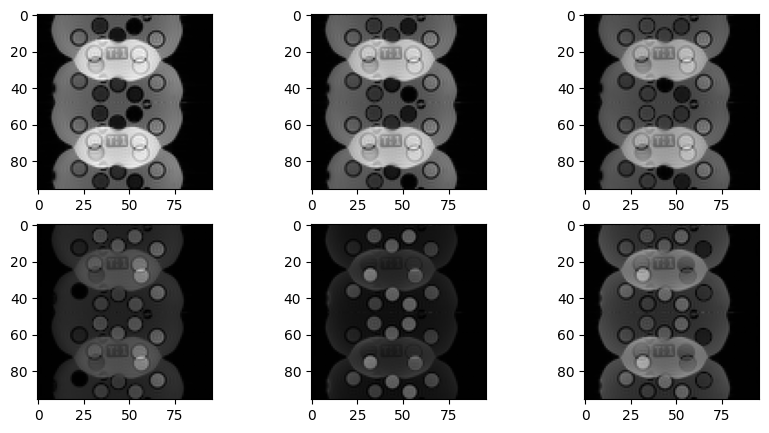

In [ ]:
# load k-space data
# fname = '/Users/nmickevicius/dev/MCW_BIOP_03-238_MRI/data/inversion_recovery_data.h5'
!wget https://github.com/nmickevicius/MCW_BIOP_03-238_MRI/raw/main/data/inversion_recovery_data.h5
fname = os.path.join(os.getcwd(), 'inversion_recovery_data.h5')
with h5py.File(fname, 'r') as F:
    ksp = F['ksp'][:]   # 2x-undersampled k-space data 
    sens = F['sens'][:] # coil sensitivity maps 
    TI = F['TI'][:]     # inversion times [sec]
    TR = F['TR'][()]    # repetition time [sec]

print(ksp.shape)
print(sens.shape) 
print(TI.shape)
print(TI)
print(TR)

# bring aliased k-space data to image domain 
img = ifft2d(ksp) 
rss = np.sqrt(np.sum(np.abs(img * img.conj()), axis=2))

# show the aliased images for each TI 
fig,ax = plt.subplots(2,3,figsize=(10,5))
for r in range(2):
    for c in range(3):
        ax[r,c].imshow(rss[:,:,r*3+c], cmap='gray', vmin=0.0, vmax=np.max(np.abs(rss)))
plt.show()

# In-Class Tasks

1. Perform a SENSE reconstruction to un-aliased the images at each inversion time
2. Estimate T1 in each voxel knowning the inversion times and reptition time